In [51]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from sympy.core.function import AppliedUndef
from typing import Optional, List, Tuple
import re
import random
import os
if not os.path.exists('plots'):
    os.makedirs('plots')

ТЕСТ: Порядок полюса (визуализация + текст)

1. P-I:  y'' = 6y² + z
Ожидается p = 2
Носитель: [(-2, 1), (0, 2), (1, 0)]
Нижняя цепь (ведущая): [(-2, 1), (0, 2)]
(-2, 1) -> (0, 2): p = 2
OK


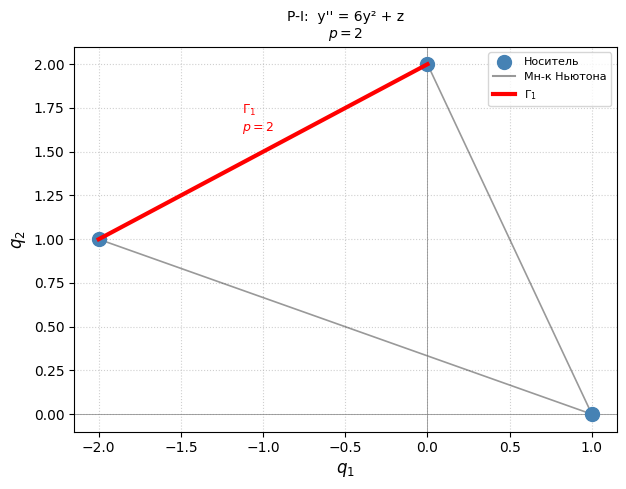


2. P-I (упрощённое):  y'' = 6y²
Ожидается p = 2
Носитель: [(-2, 1), (0, 2)]
Нижняя цепь (ведущая): [(-2, 1), (0, 2)]
(-2, 1) -> (0, 2): p = 2
OK


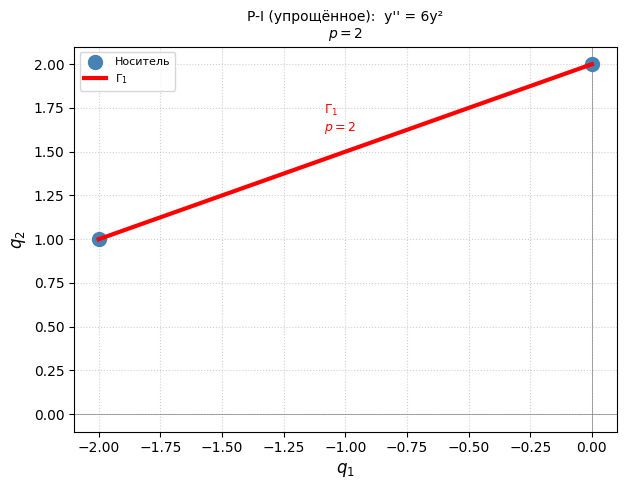


3. P-II:  y'' = 2y³ + zy + α
Ожидается p = 1
Носитель: [(-2, 1), (0, 0), (0, 3), (1, 1)]
Нижняя цепь (ведущая): [(-2, 1), (0, 3)]
(-2, 1) -> (0, 3): p = 1
OK


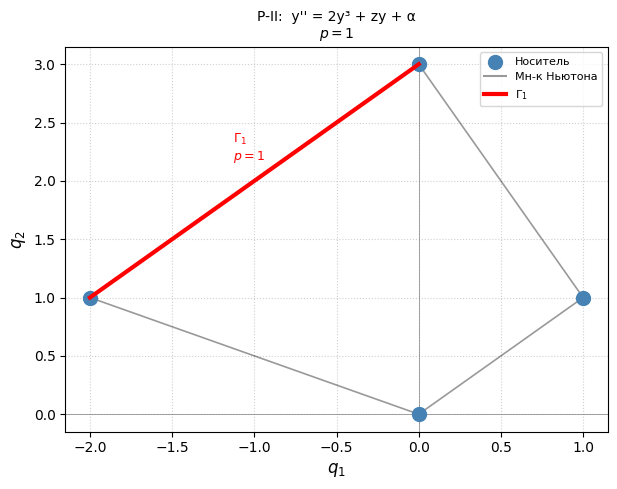


4. mKdV:  y''' + 6y²y' = 0
Ожидается p = 1
Носитель: [(-3, 1), (-1, 3)]
Нижняя цепь (ведущая): [(-3, 1), (-1, 3)]
(-3, 1) -> (-1, 3): p = 1
OK


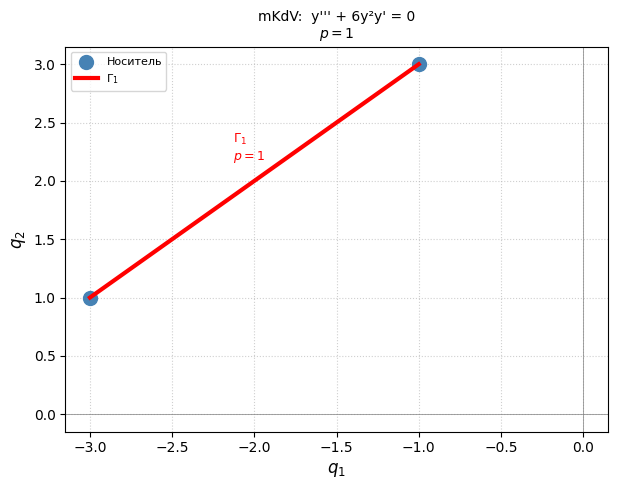


5. Бюргерс:  y'' + yy' = 0
Ожидается p = 1
Носитель: [(-2, 1), (-1, 2)]
Нижняя цепь (ведущая): [(-2, 1), (-1, 2)]
(-2, 1) -> (-1, 2): p = 1
OK


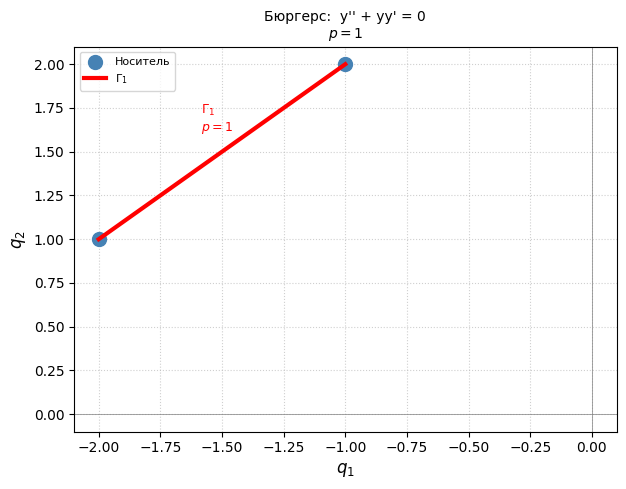


6. y' = y²
Ожидается p = 1
Носитель: [(-1, 1), (0, 2)]
Нижняя цепь (ведущая): [(-1, 1), (0, 2)]
(-1, 1) -> (0, 2): p = 1
OK


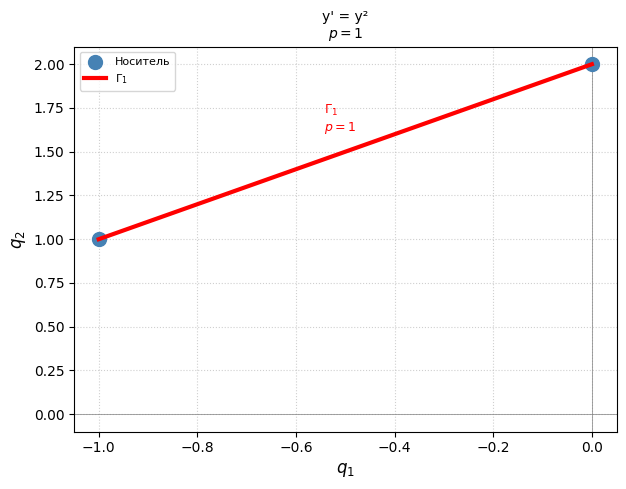


7. KdV:  y''' + y·y' = 0
Ожидается p = 2
Носитель: [(-3, 1), (-1, 2)]
Нижняя цепь (ведущая): [(-3, 1), (-1, 2)]
(-3, 1) -> (-1, 2): p = 2
OK


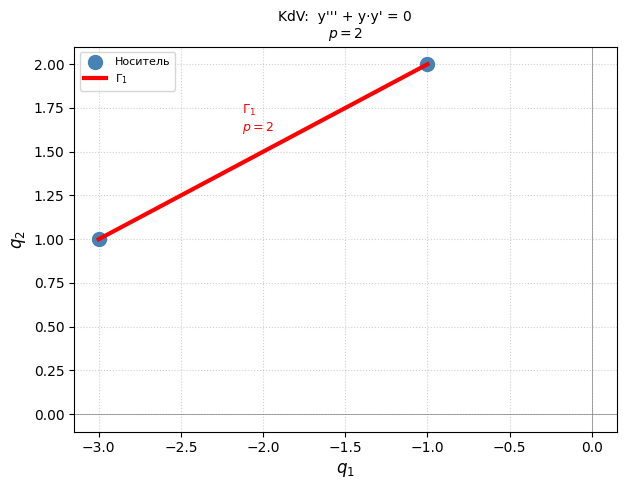


8. KS:  y'''' + y'' + y·y' = 0
Ожидается p = 3
Носитель: [(-4, 1), (-2, 1), (-1, 2)]
Нижняя цепь (ведущая): [(-4, 1), (-1, 2)]
(-4, 1) -> (-1, 2): p = 3
OK


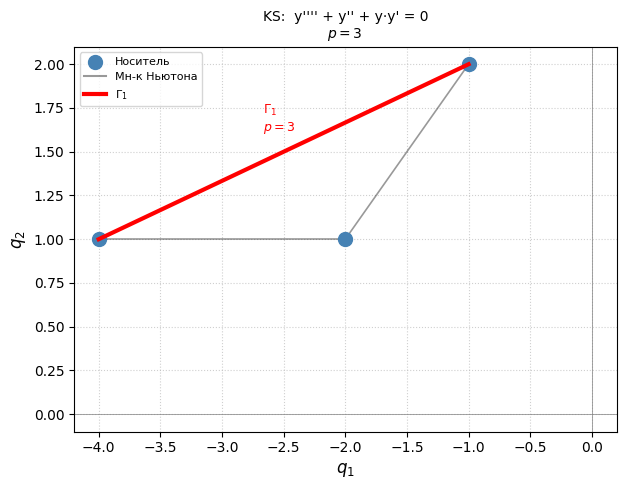


9. Курамото–Сивашинский (интегрированная форма)
Ожидается p = 3
Носитель: [(-3, 1), (-2, 1), (-1, 1), (0, 0), (0, 1), (0, 2)]
Нижняя цепь (ведущая): [(-3, 1), (0, 2)]
(-3, 1) -> (0, 2): p = 3
OK


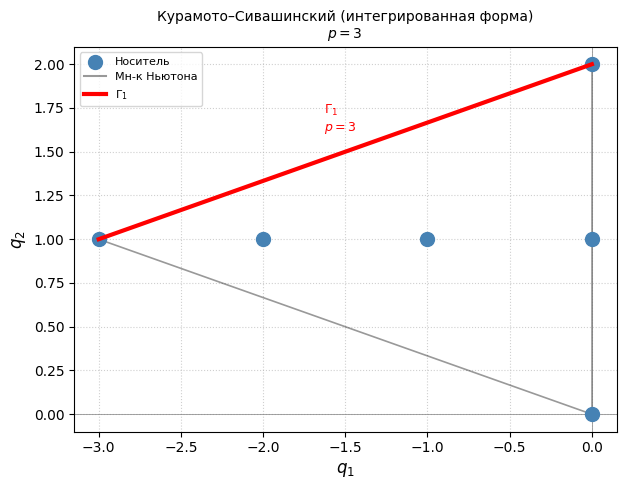


10. Обобщенное Пенлеве
Ожидается p = 4
Носитель: [(-4, 4), (-2, 2), (-1, 3), (-1, 4), (0, 3), (0, 5)]
Нижняя цепь (ведущая): [(-4, 4), (0, 5)]
(-4, 4) -> (0, 5): p = 4
OK


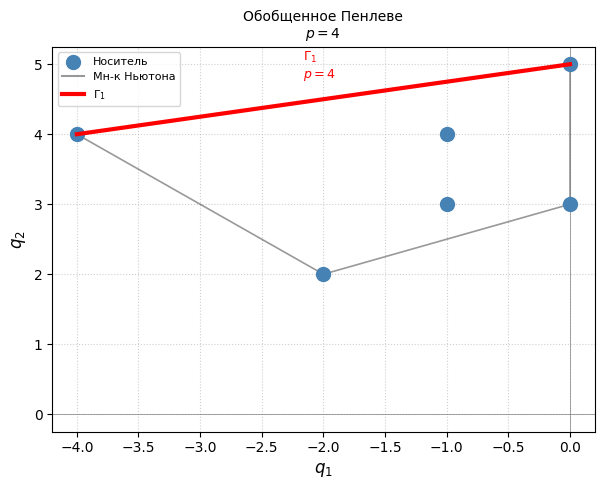


11. Эмден-Фаулер (m=2):  y'' + y² = 0
Ожидается p = 2
Носитель: [(-2, 1), (0, 2)]
Нижняя цепь (ведущая): [(-2, 1), (0, 2)]
(-2, 1) -> (0, 2): p = 2
OK


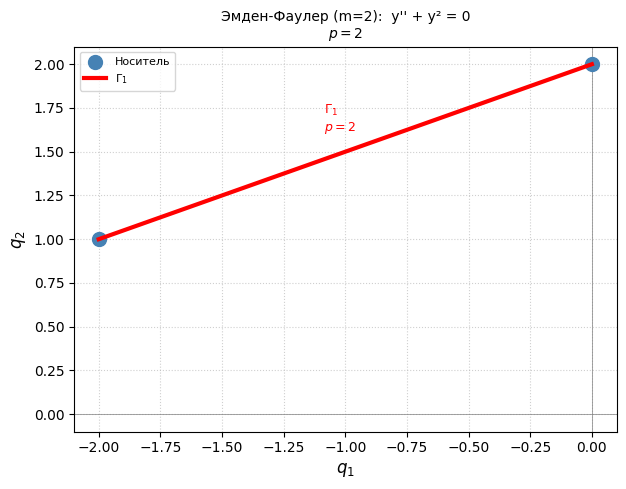


12. Эмден-Фаулер (m=3):  y'' + y³ = 0
Ожидается p = 1
Носитель: [(-2, 1), (0, 3)]
Нижняя цепь (ведущая): [(-2, 1), (0, 3)]
(-2, 1) -> (0, 3): p = 1
OK


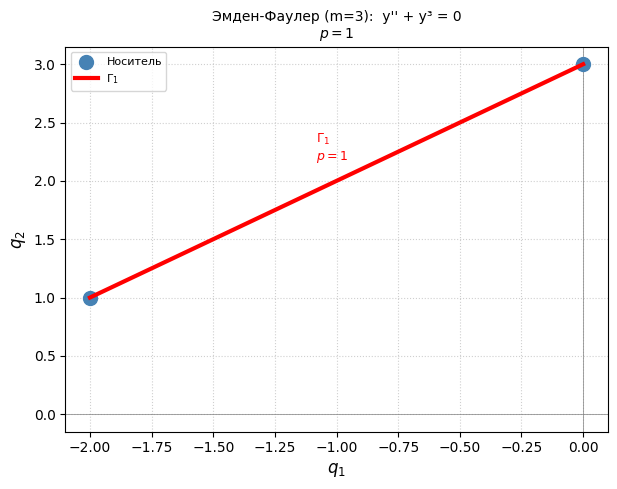


13. Эмден-Фаулер (m=4):  y'' + y⁴ = 0
Ожидается p = 2/3
Носитель: [(-2, 1), (0, 4)]
Нижняя цепь (ведущая): [(-2, 1), (0, 4)]
(-2, 1) -> (0, 4): p = 2/3
OK


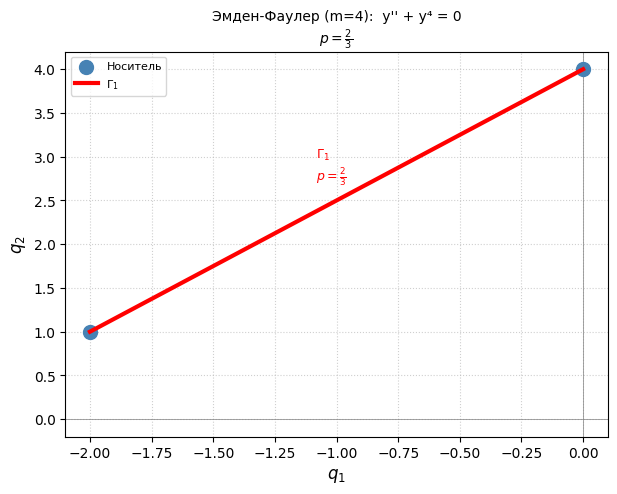


14. y'' = y⁴
Ожидается p = 2/3
Носитель: [(-2, 1), (0, 4)]
Нижняя цепь (ведущая): [(-2, 1), (0, 4)]
(-2, 1) -> (0, 4): p = 2/3
OK


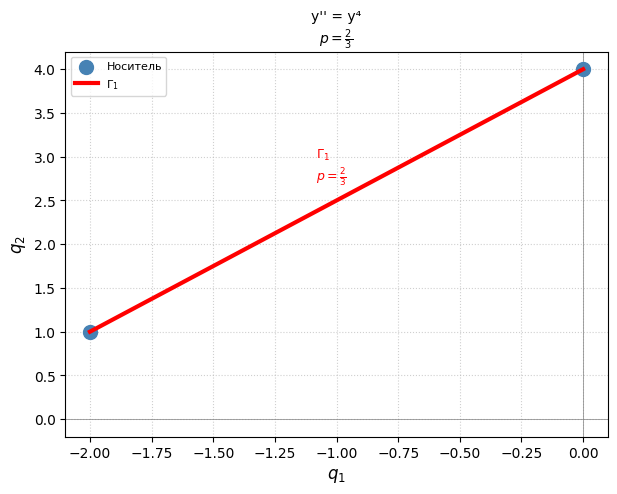


15. y'' = y⁵
Ожидается p = 1/2
Носитель: [(-2, 1), (0, 5)]
Нижняя цепь (ведущая): [(-2, 1), (0, 5)]
(-2, 1) -> (0, 5): p = 1/2
OK


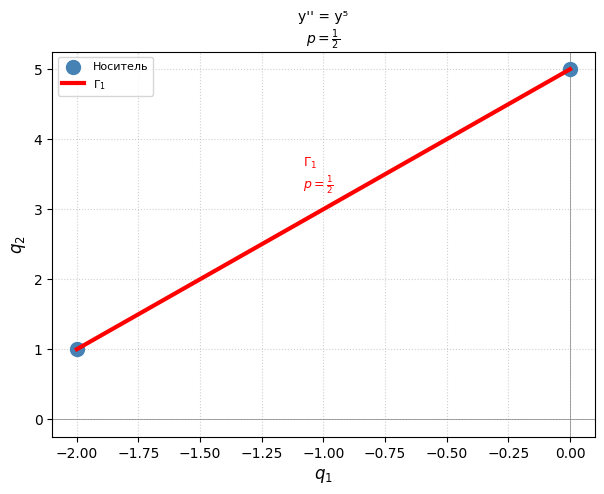


16. y'''' + y² = 0
Ожидается p = 4
Носитель: [(-4, 1), (0, 2)]
Нижняя цепь (ведущая): [(-4, 1), (0, 2)]
(-4, 1) -> (0, 2): p = 4
OK


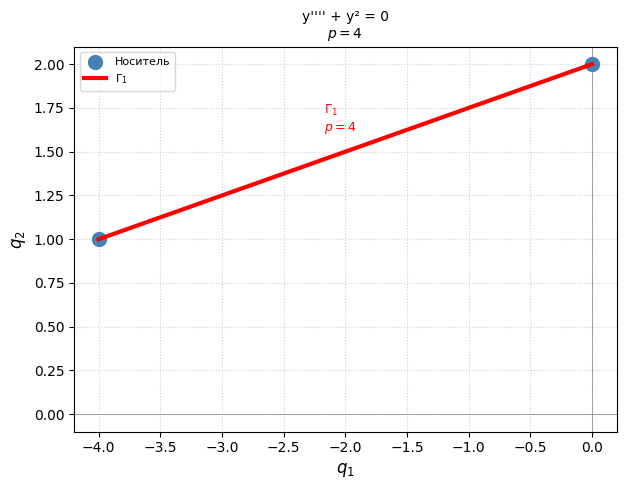


17. y'''' + y³ = 0
Ожидается p = 2
Носитель: [(-4, 1), (0, 3)]
Нижняя цепь (ведущая): [(-4, 1), (0, 3)]
(-4, 1) -> (0, 3): p = 2
OK


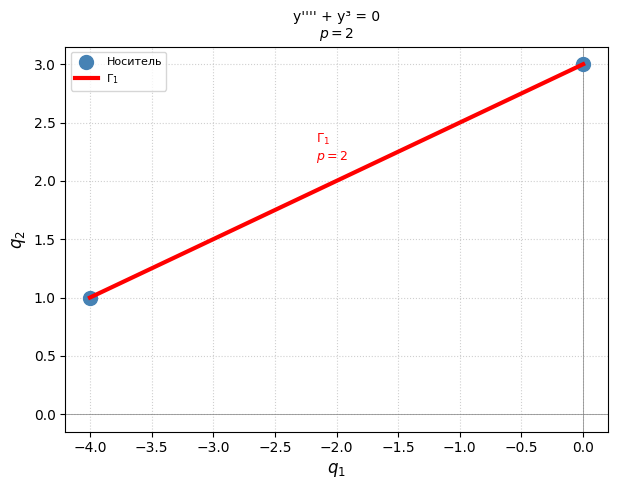


18. y''' + y² + yy' = 0
Ожидается p = 2
Носитель: [(-3, 1), (-1, 2), (0, 2)]
Нижняя цепь (ведущая): [(-3, 1), (-1, 2), (0, 2)]
(-3, 1) -> (-1, 2): p = 2
OK


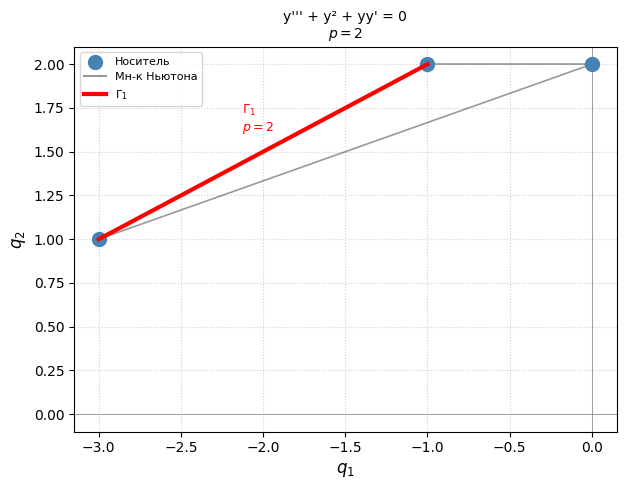


19. y'''' + y'' + y² = 0
Ожидается p = 4
Носитель: [(-4, 1), (-2, 1), (0, 2)]
Нижняя цепь (ведущая): [(-4, 1), (0, 2)]
(-4, 1) -> (0, 2): p = 4
OK


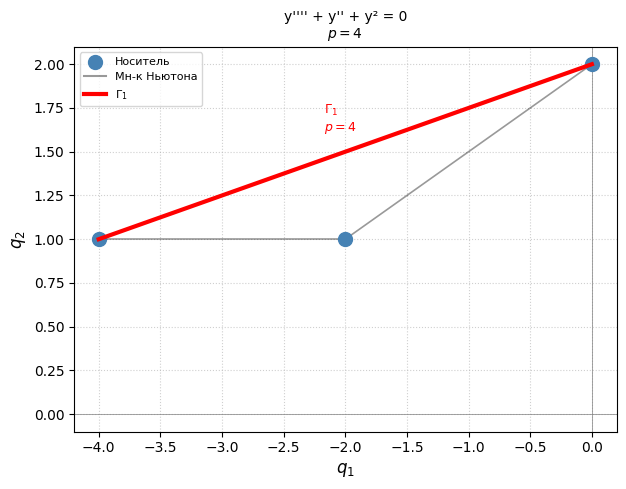


20. Фишер:  y'' + y(1-y) = 0
Ожидается p = 2
Носитель: [(-2, 1), (0, 1), (0, 2)]
Нижняя цепь (ведущая): [(-2, 1), (0, 2)]
(-2, 1) -> (0, 2): p = 2
OK


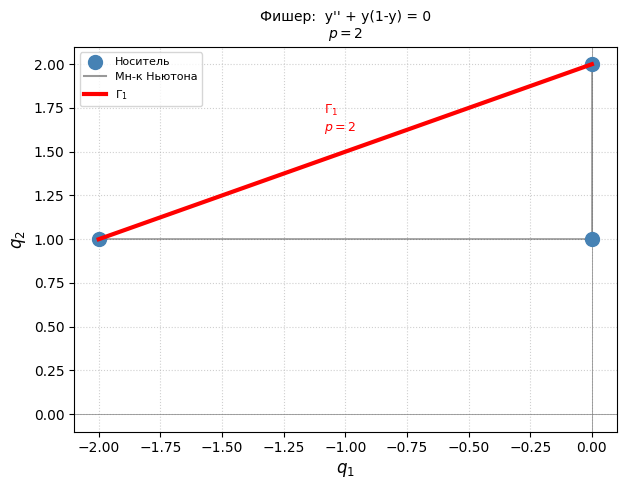


21. y'' = y³
Ожидается p = 1
Носитель: [(-2, 1), (0, 3)]
Нижняя цепь (ведущая): [(-2, 1), (0, 3)]
(-2, 1) -> (0, 3): p = 1
OK


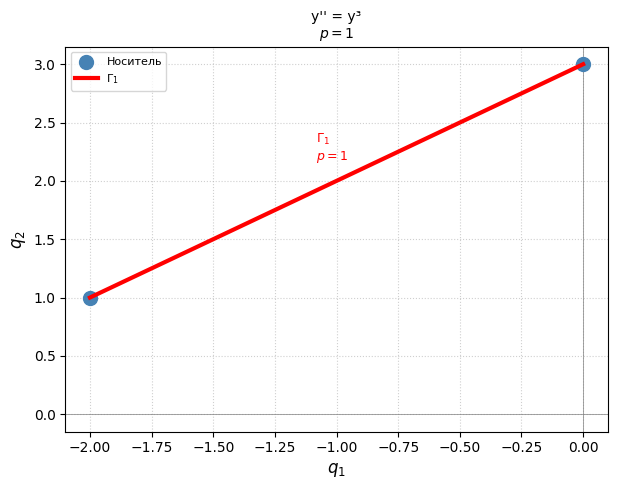


22. (y')² = y³
Ожидается p = 2
Носитель: [(-2, 2), (0, 3)]
Нижняя цепь (ведущая): [(-2, 2), (0, 3)]
(-2, 2) -> (0, 3): p = 2
OK


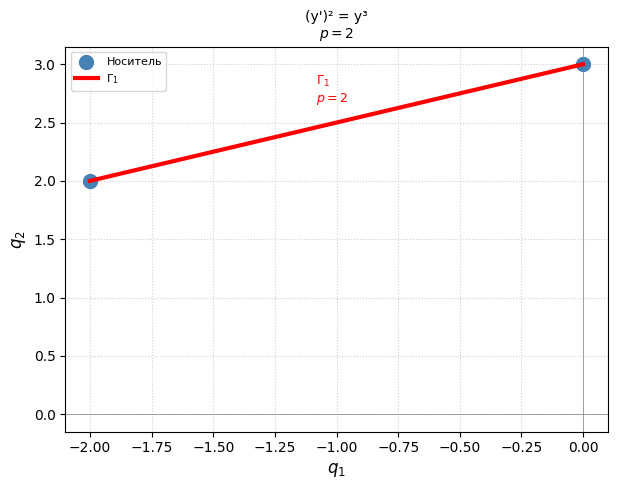


23. (y')³ = y⁴
Ожидается p = 3
Носитель: [(-3, 3), (0, 4)]
Нижняя цепь (ведущая): [(-3, 3), (0, 4)]
(-3, 3) -> (0, 4): p = 3
OK


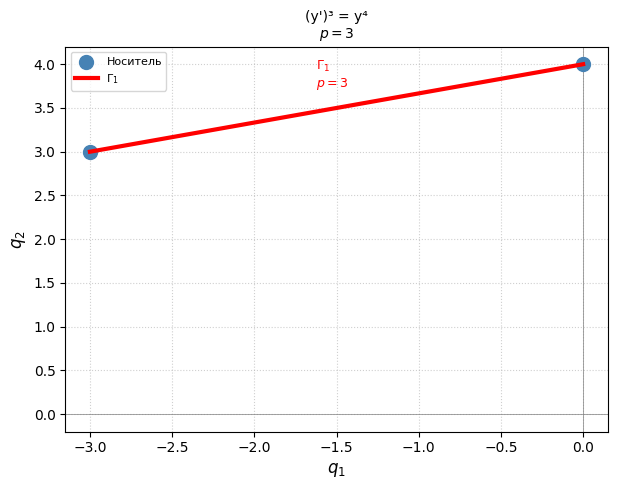


24. y''' + (y')² = 0
Ожидается p = 1
Носитель: [(-3, 1), (-2, 2)]
Нижняя цепь (ведущая): [(-3, 1), (-2, 2)]
(-3, 1) -> (-2, 2): p = 1
OK


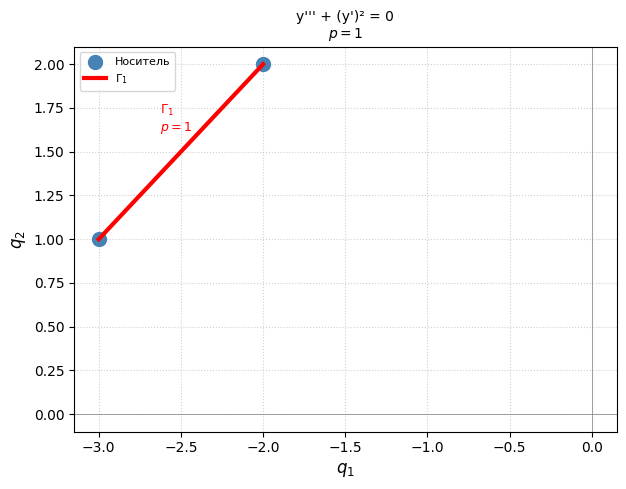


25. y'''' + (y'')² = 0
Ожидается p = None
Носитель: [(-4, 1), (-4, 2)]
OK


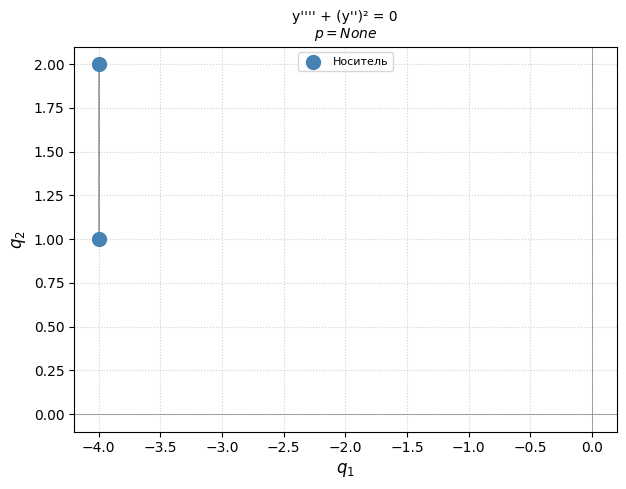


26. Gardner:  y''' + yy' + y²y' = 0
Ожидается p = 1
Носитель: [(-3, 1), (-1, 2), (-1, 3)]
Нижняя цепь (ведущая): [(-3, 1), (-1, 3)]
(-3, 1) -> (-1, 3): p = 1
OK


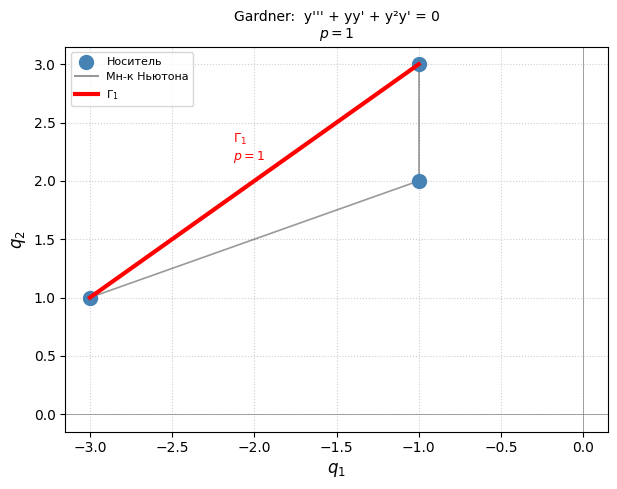


27. Линейное:  y'' + y = 0
Ожидается p = None
Носитель: [(-2, 1), (0, 1)]
OK


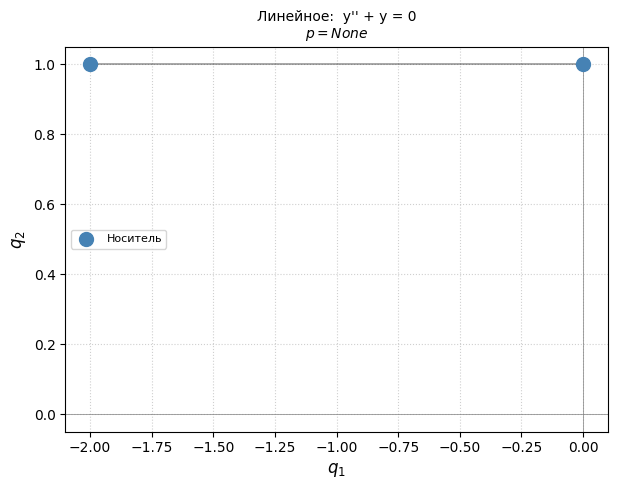


28. Линейное:  y''' + y' + y = 0
Ожидается p = None
Носитель: [(-3, 1), (-1, 1), (0, 1)]
OK


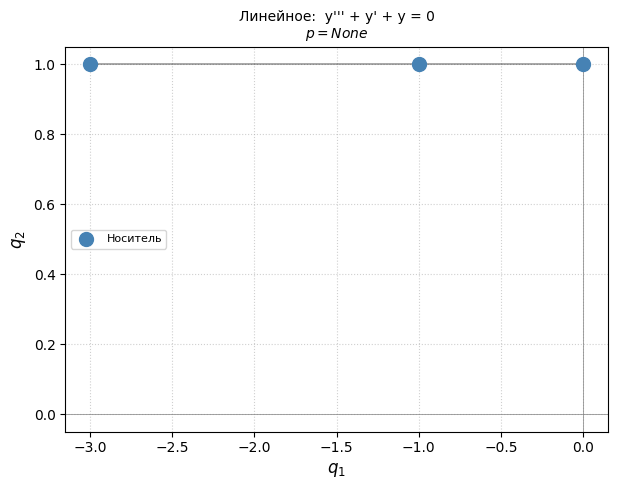


29. Без производной: y^4z^3 + 3y^3 + 3yz^2 + 5yz + z^4 = 0
Ожидается p = None
Носитель: [(0, 3), (1, 1), (2, 1), (3, 4), (4, 0)]
OK


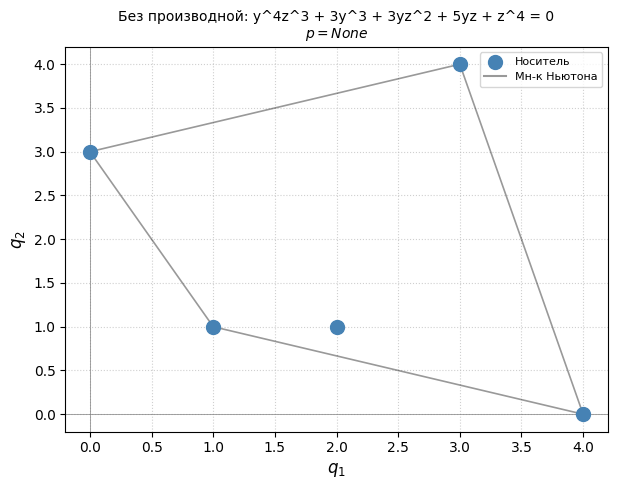


30. Сложный случай: y'''' + y^2y'' + yy' + y^4 + 1 = 0
Ожидается p = 1
Носитель: [(-4, 1), (-2, 3), (-1, 2), (0, 0), (0, 4)]
Нижняя цепь (ведущая): [(-4, 1), (-2, 3), (0, 4)]
(-4, 1) -> (-2, 3): p = 1
OK


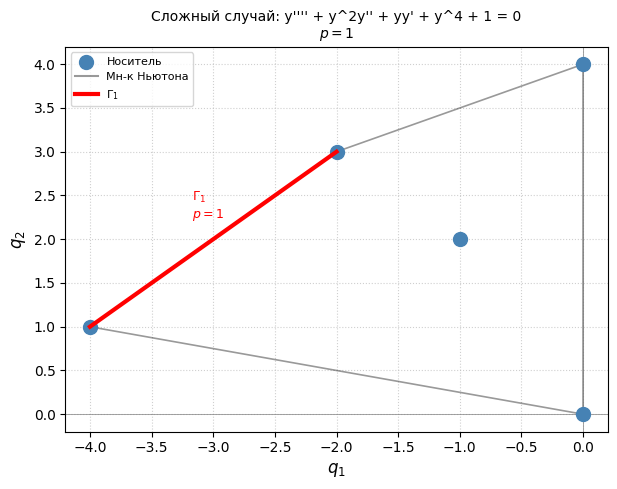


════════════════════════════════════════════════════════════════════════════════
№ Уравнение                                               p (найдено)   Статус
────────────────────────────────────────────────────────────────────────────────
 1 P-I:  y'' = 6y² + z                                          2       OK
 2 P-I (упрощённое):  y'' = 6y²                                 2       OK
 3 P-II:  y'' = 2y³ + zy + α                                    1       OK
 4 mKdV:  y''' + 6y²y' = 0                                      1       OK
 5 Бюргерс:  y'' + yy' = 0                                      1       OK
 6 y' = y²                                                      1       OK
 7 KdV:  y''' + y·y' = 0                                        2       OK
 8 KS:  y'''' + y'' + y·y' = 0                                  3       OK
 9 Курамото–Сивашинский (интегрированная форма)                 3       OK
10 Обобщенное Пенлеве                                           4       OK
11 Эмден

In [58]:
def get_monomials(expr: sp.Expr) -> List[sp.Expr]:
    return list(sp.Add.make_args(sp.expand(expr)))

def monomial_support_point(monomial: sp.Expr, y_func, z: sp.Symbol) -> Optional[Tuple[int, int]]:
    if monomial == 0: return None
    a, b, q1_d, q2_d = 0, 0, 0, 0
    for factor in sp.Mul.make_args(monomial):
        base, exp = factor.as_base_exp()
        try: exp_int = int(exp)
        except: continue
        if base == z: a += exp_int
        elif isinstance(base, AppliedUndef) and base.func == y_func.func: b += exp_int
        elif isinstance(base, sp.Derivative):
            inner = base.args[0]
            if isinstance(inner, AppliedUndef) and inner.func == y_func.func:
                k = sum(int(cnt) for _, cnt in base.args[1:])
                q1_d += (-k) * exp_int
                q2_d += exp_int
    return (a + q1_d, b + q2_d)

def compute_support(expr: sp.Expr, y_func, z: sp.Symbol) -> List[Tuple[int, int]]:
    support = set()
    for mono in get_monomials(expr):
        pt = monomial_support_point(mono, y_func, z)
        if pt is not None: support.add(pt)
    return sorted(list(support))

def find_pole_order(eq, y_func, z, verbose=False):
    if isinstance(eq, sp.Eq): expr = sp.expand(eq.lhs - eq.rhs)
    else: expr = sp.expand(eq)

    support = compute_support(expr, y_func, z)
    if verbose: print(f"Носитель: {support}")

    max_q2_map = {}
    for q1, q2 in support:
        if q1 <= 0 and q2 > 0:
            if q1 not in max_q2_map or q2 > max_q2_map[q1]:
                max_q2_map[q1] = q2

    pts = sorted(list(max_q2_map.items()))
    if len(pts) < 2: return None, support, []

    lower_chain = []
    for p in pts:
        while len(lower_chain) >= 2:
            p1, p2 = lower_chain[-2], lower_chain[-1]
            cross = (p2[0]-p1[0])*(p[1]-p1[1]) - (p2[1]-p1[1])*(p[0]-p1[0])
            if cross >= 0:
                lower_chain.pop()
            else:
                break
        lower_chain.append(p)

    if len(lower_chain) < 2:
        return None, support, []

    p1, p2 = lower_chain[0], lower_chain[1]

    if p1[1] == p2[1]:
        return None, support, []

    p_val = sp.Rational(abs(p2[0]-p1[0]), abs(p2[1]-p1[1]))

    if verbose:
        print(f"Нижняя цепь (ведущая): {lower_chain}")
        print(f"{p1} -> {p2}: p = {p_val}")

    return p_val, support, lower_chain


def plot_newton_polygon_styled(eq, y_func, z, title, p_found, support, upper_chain):
    fig, ax = plt.subplots(figsize=(7, 5))

    pts_arr = np.array(support)
    ax.scatter(pts_arr[:, 0], pts_arr[:, 1], s=100, color='steelblue', zorder=5, label='Носитель')

    if len(support) >= 3:
        try:
            hull = ConvexHull(pts_arr)
            for simplex in hull.simplices:
                ax.plot(pts_arr[simplex, 0], pts_arr[simplex, 1], 'k-', lw=1.2, alpha=0.4)
            ax.plot([], [], 'k-', alpha=0.4, label='Мн-к Ньютона')
        except:
            s_pts = pts_arr[pts_arr[:, 0].argsort()]
            ax.plot(s_pts[:, 0], s_pts[:, 1], 'k-', lw=1.2, alpha=0.4)
    elif len(support) == 2:
        ax.plot(pts_arr[:, 0], pts_arr[:, 1], 'k-', lw=1.2, alpha=0.4)

    if len(upper_chain) >= 2:
        p1, p2 = upper_chain[0], upper_chain[1]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='red', lw=3, zorder=6, label='$\\Gamma_1$')

        mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
        ax.annotate(f'$\\Gamma_1$\n$p={sp.latex(p_found)}$', (mx, my), xytext=(-15, 15),
                    textcoords='offset points', color='red', fontsize=9, fontweight='bold')

    ax.set_title(f"{title}\n$p = {sp.latex(p_found) if p_found else 'None'}$", fontsize=10)
    ax.set_xlabel('$q_1$', fontsize=12); ax.set_ylabel('$q_2$', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.legend(fontsize=8, loc='best')
    return fig

if __name__ == '__main__':
    z, alpha, sigma, gamma, mu, delta, beta, C0, C1, a, b, c = sp.symbols(
    'z alpha sigma gamma mu delta beta C0 C1 a b c'
    )
    y = sp.Function('y')

    tests = [
    ("P-I:  y'' = 6y² + z", sp.Eq(y(z).diff(z, 2), 6 * y(z)**2 + z), 2),
    ("P-I (упрощённое):  y'' = 6y²", sp.Eq(y(z).diff(z, 2), 6 * y(z)**2), 2),
    ("P-II:  y'' = 2y³ + zy + α", sp.Eq(y(z).diff(z, 2), 2 * y(z)**3 + z*y(z) + 1), 1),
    ("mKdV:  y''' + 6y²y' = 0", sp.Eq(y(z).diff(z, 3) + 6 * y(z)**2 * y(z).diff(z), 0), 1),
    ("Бюргерс:  y'' + yy' = 0", sp.Eq(y(z).diff(z, 2) + y(z) * y(z).diff(z), 0), 1),
    ("y' = y²", sp.Eq(y(z).diff(z), y(z)**2), 1),
    ("KdV:  y''' + y·y' = 0", sp.Eq(y(z).diff(z, 3) + y(z) * y(z).diff(z), 0), 2),
    ("KS:  y'''' + y'' + y·y' = 0", sp.Eq(y(z).diff(z, 4) + y(z).diff(z, 2) + y(z) * y(z).diff(z), 0), 3),
    ("Курамото–Сивашинский (интегрированная форма)", sp.Eq(y(z).diff(z, 3) + sigma*y(z).diff(z, 2) + y(z).diff(z) + sp.Rational(1, 2)*y(z)**2 + C0*y(z) - C1, 0), 3),
    ("Обобщенное Пенлеве", sp.Eq(y(z)**3 * y(z).diff(z, 4) - 4*y(z)**2 * y(z).diff(z) * y(z).diff(z, 3) + sp.Rational(21, 2)*y(z) * y(z).diff(z)**2 * y(z).diff(z, 2) - 3*y(z)**2 * y(z).diff(z, 2)**2 - sp.Rational(9, 2)*y(z).diff(z)**4 + 72*gamma*y(z)**5 - 72*mu*y(z)**3 + sp.Rational(1, 2)*gamma*y(z)*y(z).diff(z, 2) - sp.Rational(1, 2)*mu*y(z)**2*y(z).diff(z) + sp.Rational(1, 2)*y(z)**3*y(z).diff(z), 0), 4),
    ("Эмден-Фаулер (m=2):  y'' + y² = 0", sp.Eq(y(z).diff(z, 2) + y(z)**2, 0), 2),
    ("Эмден-Фаулер (m=3):  y'' + y³ = 0", sp.Eq(y(z).diff(z, 2) + y(z)**3, 0), 1),
    ("Эмден-Фаулер (m=4):  y'' + y⁴ = 0", sp.Eq(y(z).diff(z, 2) + y(z)**4, 0), sp.Rational(2, 3)),
    ("y'' = y⁴", sp.Eq(y(z).diff(z, 2), y(z)**4), sp.Rational(2, 3)),
    ("y'' = y⁵", sp.Eq(y(z).diff(z, 2), y(z)**5), sp.Rational(1, 2)),
    ("y'''' + y² = 0", sp.Eq(y(z).diff(z, 4) + y(z)**2, 0), 4),
    ("y'''' + y³ = 0", sp.Eq(y(z).diff(z, 4) + y(z)**3, 0), 2),
    ("y''' + y² + yy' = 0", sp.Eq(y(z).diff(z, 3) + y(z)**2 + y(z)*y(z).diff(z), 0), 2),
    ("y'''' + y'' + y² = 0", sp.Eq(y(z).diff(z, 4) + y(z).diff(z, 2) + y(z)**2, 0), 4),
    ("Фишер:  y'' + y(1-y) = 0", sp.Eq(y(z).diff(z, 2) + y(z)*(1 - y(z)), 0), 2),
    ("y'' = y³", sp.Eq(y(z).diff(z, 2), y(z)**3), 1),
    ("(y')² = y³", sp.Eq(y(z).diff(z)**2, y(z)**3), 2),
    ("(y')³ = y⁴", sp.Eq(y(z).diff(z)**3, y(z)**4), 3),
    ("y''' + (y')² = 0", sp.Eq(y(z).diff(z, 3) + y(z).diff(z)**2, 0), 1),
    ("y'''' + (y'')² = 0",sp.Eq(y(z).diff(z, 4) + y(z).diff(z, 2)**2, 0), None),
    ("Gardner:  y''' + yy' + y²y' = 0", sp.Eq(y(z).diff(z, 3) + y(z)*y(z).diff(z) + y(z)**2*y(z).diff(z), 0), 1),
    ("Линейное:  y'' + y = 0", sp.Eq(y(z).diff(z, 2) + y(z), 0), None),
    ("Линейное:  y''' + y' + y = 0", sp.Eq(y(z).diff(z, 3) + y(z).diff(z) + y(z), 0), None),
    ("Без производной: y^4z^3 + 3y^3 + 3yz^2 + 5yz + z^4 = 0", sp.Eq(y(z)**4*z**3+3*y(z)**3+3*y(z)*z**2+5*y(z)*z+z**4,0),None),
    ("Сложный случай: y'''' + y^2y'' + yy' + y^4 + 1 = 0", sp.Eq(y(z).diff(z,4)+y(z)**2*y(z).diff(z,2)+y(z)*y(z).diff(z,1)
           +y(z)**4+1, 0), 1)
    ]

    print('='*60)
    print('ТЕСТ: Порядок полюса (визуализация + текст)')
    print('='*60)

    results = []
    passed = 0
    for i, (desc, eq, expected) in enumerate(tests):
        print(f"\n{i+1}. {desc}")
        print(f"Ожидается p = {expected}")
        p_val, support, chain = find_pole_order(eq, y(z), z, verbose=True)
        results.append((desc, p_val, expected))

        mark = 'OK' if p_val == expected else 'NOT OK'
        if p_val == expected: passed += 1
        print(mark)

        fig = plot_newton_polygon_styled(eq, y(z), z, desc, p_val, support, chain)
        fname = f"plots/newton_{i+1:02d}.png"
        fig.savefig(fname, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close(fig)


    print('\n' + '═' * 80)
    print(f"{'№':2}{'Уравнение':<55} {'p (найдено)':>6} {'Статус':>8}")
    print('─' * 80)
    for i, (name, p, exp) in enumerate(results):
        status = "OK" if p == exp else "FAIL"
        print(f"{i+1:2} {name:55} {str(p) if p else '-':>6} {status:>8}")
    print('═' * 70)

    print(f'Пройдено: {passed}/{len(tests)}\n')

--- Генерация уравнения по заданному носителю ---
Сгенерированные точки: [(-2, 1), (0, 2), (1, 1), (-1, 0)]
Полученное уравнение: 3y^2 + 2yz + 5y'' + 2/z = 0


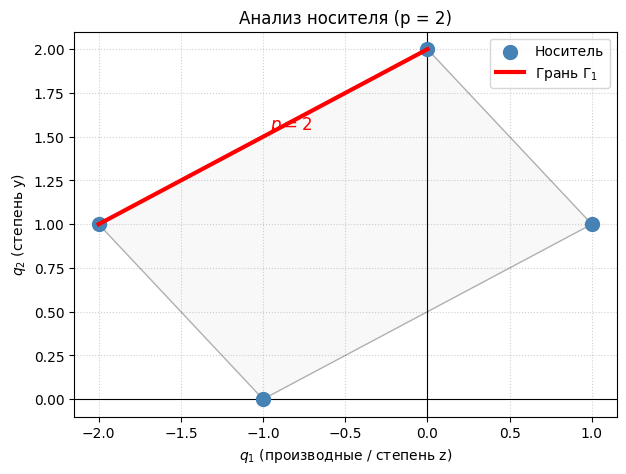


--- Проверка сгенерированного уравнения ---
Носитель: [(-2, 1), (-1, 0), (0, 2), (1, 1)]
Нижняя цепь (ведущая): [(-2, 1), (0, 2)]
(-2, 1) -> (0, 2): p = 2
Результат анализа: p = 2


In [53]:
def point_to_monomial(q1, q2, y_func, z_sym):
    y = y_func
    z = z_sym

    if q1 <= 0:
        k = abs(q1)
        if q2 < 1:
            return z**q1 * y**q2

        deriv = sp.diff(y, z, k)
        poly_part = y**(q2 - 1)
        return poly_part * deriv

    else:
        return z**q1 * y**q2

def generate_equation_from_support(points, y_func, z_sym):
    expr = 0
    for pt in points:
        q1, q2 = pt
        coeff = random.randint(1, 5)
        mono = point_to_monomial(q1, q2, y_func, z_sym)
        expr += coeff * mono
    return sp.Eq(expr, 0)

def pretty_format_ode(equation):
    if isinstance(equation, sp.Eq):
        expr = equation.lhs - equation.rhs
    else:
        expr = equation

    for order in range(10, 0, -1):
        deriv_repr = "y" + "'" * order
        expr = expr.replace(sp.Derivative(y, z, order), sp.Symbol(deriv_repr))

    expr = expr.replace(y, sp.Symbol('y'))

    s = str(expr)
    s = s.replace('**', '^')
    s = s.replace('*', '')

    return f"{s} = 0"

def plot_newton_polygon(support):
    pts_arr = np.array(support)
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(pts_arr[:, 0], pts_arr[:, 1], s=100, color='steelblue', zorder=5, label='Носитель')

    if len(support) >= 3:
        try:
            hull = ConvexHull(pts_arr)
            for simplex in hull.simplices:
                ax.plot(pts_arr[simplex, 0], pts_arr[simplex, 1], 'k-', lw=1, alpha=0.3)
            ax.fill(pts_arr[hull.vertices,0], pts_arr[hull.vertices,1], 'gray', alpha=0.05)
        except: pass

    max_q2_map = {}
    for q1, q2 in support:
        if q1 <= 0 and q2 > 0:
            if q1 not in max_q2_map or q2 > max_q2_map[q1]:
                max_q2_map[q1] = q2

    relevant_pts = sorted(list(max_q2_map.items()))

    p_val = None
    if len(relevant_pts) >= 2:
        upper = []
        for p in relevant_pts:
            while len(upper) >= 2:
                p1, p2 = upper[-2], upper[-1]
                cross = (p2[0]-p1[0])*(p[1]-p1[1]) - (p2[1]-p1[1])*(p[0]-p1[0])
                if cross >= 0: upper.pop()
                else: break
            upper.append(p)

        if len(upper) >= 2:
            p1, p2 = upper[0], upper[1]
            if abs(p2[1] - p1[1]) != 0:
                p_val = sp.Rational(abs(p2[0] - p1[0]), abs(p2[1] - p1[1]))

                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='red', lw=3, zorder=6, label='Грань $\\Gamma_1$')

                mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
                ax.annotate(f'$p={sp.latex(p_val)}$', (mx, my), xytext=(5, 5),
                            textcoords='offset points', color='red', fontsize=12, fontweight='bold')

    ax.set_title(f"Анализ носителя (p = {p_val if p_val else 'None'})")
    ax.set_xlabel('$q_1$ (производные / степень z)')
    ax.set_ylabel('$q_2$ (степень y)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.axhline(0, color='black', lw=0.8); ax.axvline(0, color='black', lw=0.8)
    ax.legend()
    plt.show()


if __name__ == "__main__":
    z = sp.Symbol('z')
    y = sp.Function('y')(z)

    print("--- Генерация уравнения по заданному носителю ---")
    target_support = [(-2, 1), (0, 2), (1, 1), (-1, 0)]

    generated_eq = generate_equation_from_support(target_support, y, z)
    print(f"Сгенерированные точки: {target_support}")
    print(f"Полученное уравнение: {pretty_format_ode(generated_eq)}")

    fig = plot_newton_polygon(target_support)

    print("\n--- Проверка сгенерированного уравнения ---")
    try:
        p_val, support, upper = find_pole_order(generated_eq, y, z, verbose=True)
        print(f"Результат анализа: p = {p_val}")
    except Exception as e:
        print(f"Ошибка при проверке: {e}")